In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/adhee/INFOSYS/Milestones/Milestone1/data/Clean-Data")
df

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,0,0,28,0,28.0
1,2023-01-01 01:00:00,119,0,84,0,203.0
2,2023-01-01 02:00:00,135,0,47,0,182.0
3,2023-01-01 03:00:00,171,0,21,0,192.0
4,2023-01-01 04:00:00,0,0,88,0,88.0
...,...,...,...,...,...,...
4316,2023-06-29 20:00:00,146,2221,23,0,2390.0
4317,2023-06-29 21:00:00,72,1887,31,0,1990.0
4318,2023-06-29 22:00:00,156,1982,0,0,2138.0
4319,2023-06-29 23:00:00,149,1143,43,0,1335.0


In [8]:
target_col = 'total_power'

In [9]:
from numpy import polyfit
def hurts(ts):
    lags = range(2,100)
    tau =[np.sqrt(np.std(np.subtract(ts[lag:],ts[:-lag])))for lag in lags]
    poly = np.polyfit(np.log(lags),np.log(tau),1)
    return poly[0]*2.0

h_exp = hurts(df[target_col].dropna().values)
# h_exp = hurts(ts)
print(f"Hurst Expoenent of {target_col}: {h_exp:.4f}")
if h_exp>0.5:
    print("The series is persistent(Trending)")
else:
    print("The series is Anti-Persistent(Mean-Reverting)")

Hurst Expoenent of total_power: 0.0077
The series is Anti-Persistent(Mean-Reverting)


In [10]:
df[target_col]

0         28.0
1        203.0
2        182.0
3        192.0
4         88.0
         ...  
4316    2390.0
4317    1990.0
4318    2138.0
4319    1335.0
4320    1107.0
Name: total_power, Length: 4321, dtype: float64

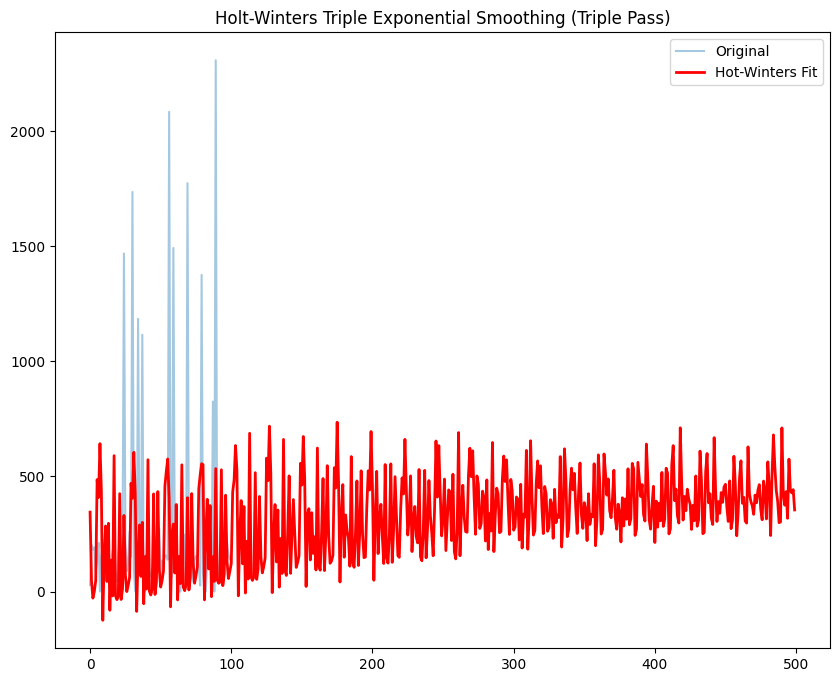

In [11]:
# HOLT WInters Triple Exponential Smoothing


from statsmodels.tsa.holtwinters import ExponentialSmoothing
model_hw = ExponentialSmoothing(df[target_col][:500],seasonal_periods = 24, trend = 'add',seasonal = 'add').fit()
df_forecart =model_hw.fittedvalues

df_forecart

plt.figure(figsize = (10,8))
plt.plot(df[target_col][:100],label = 'Original',alpha = 0.4)
plt.plot(df_forecart,label = 'Hot-Winters Fit',color = 'red',linewidth=2)
plt.title('Holt-Winters Triple Exponential Smoothing (Triple Pass)')
plt.legend()
plt.show()

<Figure size 800x600 with 0 Axes>

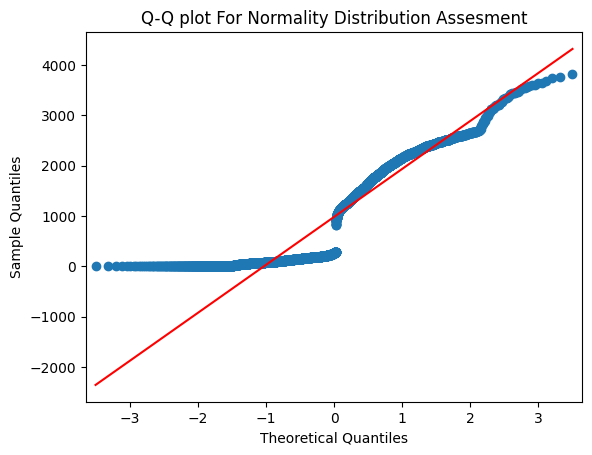

In [12]:
import statsmodels.api as sm
plt.figure(figsize = (8,6))
sm.qqplot(df[target_col],line = 's')
plt.title('Q-Q plot For Normality Distribution Assesment')
plt.show()

<Figure size 800x600 with 0 Axes>

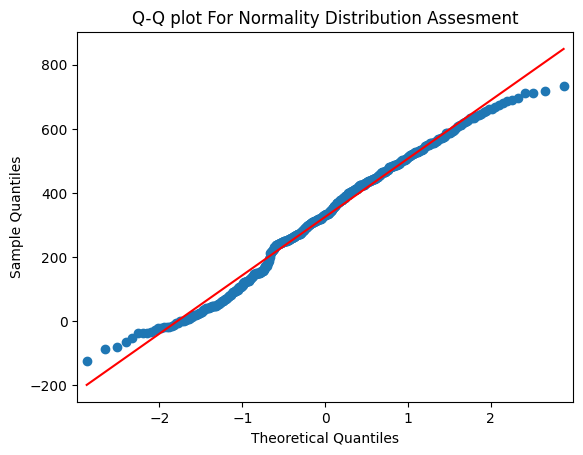

In [13]:
import statsmodels.api as sm
plt.figure(figsize = (8,6))
sm.qqplot(df_forecart,line = 's')
plt.title('Q-Q plot For Normality Distribution Assesment')
plt.show()

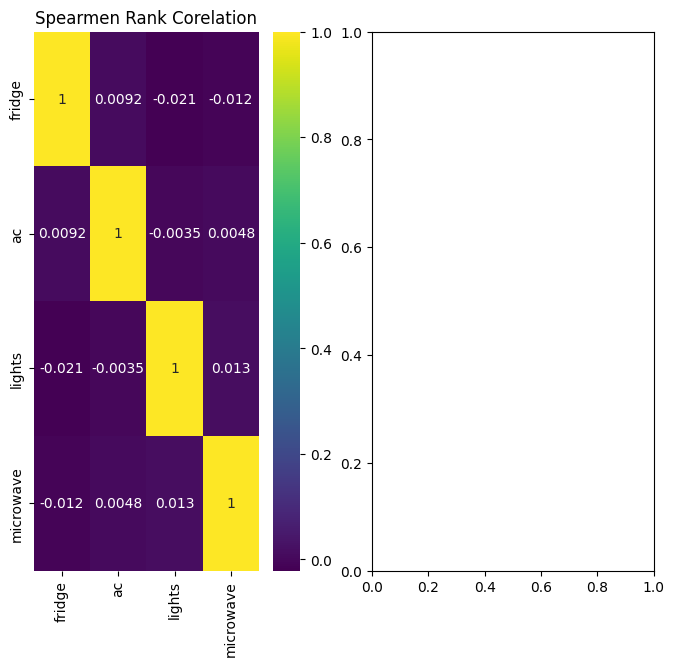

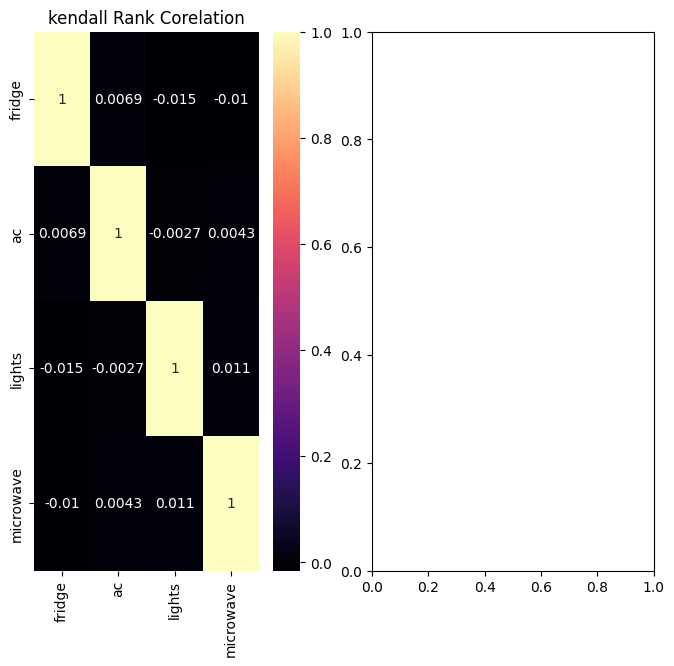

In [14]:
device_cols = ['fridge','ac','lights','microwave']
existing = [c for c in device_cols if c in df.columns]

if existing:
    spearmen_corr = df[existing].corr(method = 'spearman')
    kendall_corr = df[existing].corr(method = 'kendall')

    fig,(ax1,ax2) = plt.subplots(1,2,figsize =(8,7))
    sns.heatmap(spearmen_corr,annot = True,ax=ax1,cmap='viridis')
    ax1.set_title("Spearmen Rank Corelation")

    fig,(ax1,ax2) = plt.subplots(1,2,figsize =(8,7))
    sns.heatmap(kendall_corr,annot = True,ax=ax1,cmap='magma')
    ax1.set_title("kendall Rank Corelation")